In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import rotation_utils



/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/miniconda3/envs/quantsam/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWar

##Test the effect of the range of the weight

In [ ]:
import torch.nn as nn
import os
import sys
# root = os.path.dirname(os.path.abspath(__file__))
root = "/home/ubuntu/21chi.nh/Quantization/SAM_Quantization/SAM_Quantization"
print(root)
sys.path.insert(0,root)
from RTN_quantization.utils import replace_linear_with_quantized, QuantizationConfig
from RTN_quantization.per_tensor_channel_group import W8A8Linear
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(1000, 128)  # Embedding layer
        self.linear_1 = nn.Linear(128, 256)  # First linear layer
        self.linear_2 = nn.Linear(256, 128, bias=False)  # Second linear layer (no bias)
        self.lm_head = nn.Linear(128, 1000, bias=False)  # Output head
    
    def forward(self, x):
        x = self.emb(x)
        x = self.linear_1(x)
        x = torch.relu(x)
        x = self.linear_2(x)
        x = torch.relu(x)
        x = self.lm_head(x)
        return x

model = DummyModel()
config = QuantizationConfig(
    n_bits_w=4,
    n_bits_a=4,
    weight_quant="per_channel",
    act_quant="per_token"
)
replace_linear_with_quantized(
    module=model, 
    config=config,
    module_name_to_exclude=["emb", "lm_head"]
)

In [13]:
import random

def initialize_linear_params(model, min_val, max_val, seed=42):
    """
    Initialize parameters of all linear layers in a model within a specified range.

    Args:
        model (nn.Module): The PyTorch model
        min_val (float): Minimum value for initialization
        max_val (float): Maximum value for initialization
        seed (int): Random seed for reproducibility

    Returns:
        model (nn.Module): Model with initialized parameters
    """
    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Function to initialize tensor with uniform distribution
    def init_tensor(tensor):
        nn.init.uniform_(tensor, min_val, max_val)

    # Iterate through all modules
    for module in model.modules():
        if isinstance(module, nn.Linear):
            # Initialize weights
            init_tensor(module.weight)
            # Initialize bias if it exists
            if module.bias is not None:
                init_tensor(module.bias)

    return model
def compare_model_outputs(orig_model, quant_model, input_data, top_k=5):
    """
    Compare outputs between original and quantized models.

    Args:
        orig_model (nn.Module): Original model
        quant_model (nn.Module): Quantized model
        input_data (torch.Tensor): Input data
        top_k (int): Number of top predictions to compare

    Returns:
        dict: Dictionary with comparison metrics
    """
    # Set models to evaluation mode
    orig_model.eval()
    quant_model.eval()

    # Forward pass
    with torch.no_grad():
        orig_output = orig_model(input_data)
        quant_output = quant_model(input_data)

    # Calculate metrics
    mse = torch.mean((orig_output - quant_output) ** 2).item()
    cos_sim = torch.nn.functional.cosine_similarity(
        orig_output.view(orig_output.size(0), -1), 
        quant_output.view(quant_output.size(0), -1)
    ).mean().item()

    # Calculate top-k accuracy
    _, orig_top_k = torch.topk(orig_output, top_k, dim=-1)
    _, quant_top_k = torch.topk(quant_output, top_k, dim=-1)

    # Check how many top-k predictions match between models
    top_k_match = torch.sum(
        torch.any(orig_top_k.unsqueeze(-1) == quant_top_k.unsqueeze(-2), dim=-1)
    ).item() / (orig_top_k.size(0) * orig_top_k.size(1))

    return {
        "MSE": mse,
        "Cosine Similarity": cos_sim,
        "Top-K Match Rate": top_k_match,
        "Original Output Shape": list(orig_output.shape),
        "Quantized Output Shape": list(quant_output.shape)
    }

In [ ]:
def test_quantization_with_dummy_model(batch_size=8, seq_len=16):
    # Create and initialize original model
    original_model = DummyModel()
    import copy
    second_original_model = copy.deepcopy(original_model)
    original_model = initialize_linear_params(original_model, min_val=0, max_val=10, seed=42)
    
    second_original_model = initialize_linear_params(second_original_model, min_val=-10, max_val=10, seed=42)
    # Create a copy for quantization
    
    quantized_model = copy.deepcopy(original_model)
    second_quantized_model = copy.deepcopy(second_original_model)
    # Apply quantization to the copied model
    config = QuantizationConfig(
        n_bits_w=4,
        n_bits_a=4,
        weight_quant="per_channel",
        act_quant="per_token"
    )
    replace_linear_with_quantized(
        module=quantized_model,
        config=config,
        module_name_to_exclude=["emb", "lm_head"]
    )
    config2 = QuantizationConfig(
        n_bits_w=8,
        n_bits_a=8,
        weight_quant="per_channel",
        act_quant="per_token"
    )
    replace_linear_with_quantized(
        module=second_quantized_model,
        config=config2,
        module_name_to_exclude=["emb", "lm_head"]
    )

    # Generate random input data
    # For the dummy model, inputs should be integer indices for the embedding layer
    input_data = torch.randint(0, 1000, (batch_size, seq_len))

    # Compare outputs
    comparison_results = compare_model_outputs(original_model, quantized_model, input_data)
    second_comparison_results = compare_model_outputs(second_original_model, second_quantized_model, input_data)
    # Print results
    print("Comparison between Original and Quantized Model:")
    for metric, value in comparison_results.items():
        print(f"{metric}: {value}")
    print("\nComparison between Second Original and Second Quantized Model:")
    for metric, value in second_comparison_results.items():
        print(f"{metric}: {value}")
 

# Run the test
test_quantization_with_dummy_model()

In [ ]:
def test_quantization_with_dummy_model(batch_size=8, seq_len=16):
    # Create and initialize original model
    original_model = DummyModel()
    original_model = initialize_linear_params(original_model, min_val=-10, max_val=10, seed=42)

    # Create a copy for quantization
    import copy
    quantized_model = copy.deepcopy(original_model)

    # Apply quantization to the copied model
    config = QuantizationConfig(
        n_bits_w=4,
        n_bits_a=4,
        weight_quant="per_channel",
        act_quant="per_token"
    )
    replace_linear_with_quantized(
        module=quantized_model,
        config=config,
        module_name_to_exclude=["emb", "lm_head"]
    )

    # Generate random input data
    # For the dummy model, inputs should be integer indices for the embedding layer
    input_data = torch.randint(0, 1000, (batch_size, seq_len))

    # Compare outputs
    comparison_results = compare_model_outputs(original_model, quantized_model, input_data)

    # Print results
    print("Comparison between Original and Quantized Model:")
    for metric, value in comparison_results.items():
        print(f"{metric}: {value}")

    return original_model, quantized_model, input_data, comparison_results

# Run the test
original_model, quantized_model, input_data, results = test_quantization_with_dummy_model()

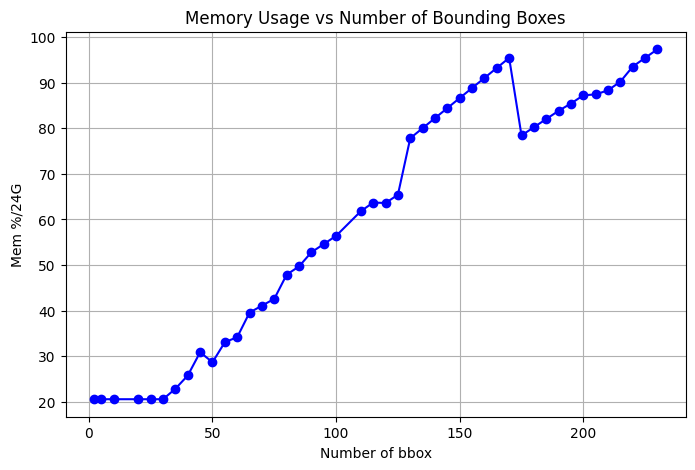

In [2]:
import matplotlib.pyplot as plt

# Data
arr1 = [2, 5, 10, 20, 25, 30, 35, 40, 45, 50, 55, 60,
        65, 70, 75, 80, 85, 90, 95, 100, 110, 115, 120,
        125, 130, 135, 140, 145, 150, 155, 160, 165,
        170, 175, 180, 185, 190, 195, 200, 205, 210,
        215, 220, 225, 230]

arr2 = [20.6, 20.6, 20.6, 20.6, 20.6, 20.6, 22.9, 25.8, 30.9, 28.7, 
        33.1, 34.2, 39.6, 41.1, 42.6, 47.9, 49.7, 52.8, 54.6, 56.4, 
        61.8, 63.7, 63.6, 65.4, 77.8, 80, 82.2, 84.4, 86.6, 88.8, 
        91, 93.2, 95.4, 78.4, 80.2, 82, 83.8, 85.4, 87.2, 87.4, 
        88.3, 90.2, 93.5, 95.4, 97.3]
# Plot
plt.figure(figsize=(8,5))
plt.plot(arr1, arr2, marker='o', linestyle='-', color='b')

# Labels
plt.xlabel("Number of bbox")
plt.ylabel("Mem %/24G")
plt.title("Memory Usage vs Number of Bounding Boxes")

# Grid
plt.grid(True)

plt.show()

In [3]:
def generate_matrix_with_outliers(rows, cols, outlier_ratio=0.1, normal_std=1.0, outlier_std=10.0, seed=42):
    """
    Generate a matrix with values sampled from two distinct normal distributions.
    
    Args:
        rows (int): Number of rows
        cols (int): Number of columns
        outlier_ratio (float): Proportion of values that are outliers (0-1)
        normal_std (float): Standard deviation for normal values
        outlier_std (float): Standard deviation for outlier values
        seed (int): Random seed for reproducibility
    
    Returns:
        torch.Tensor: Matrix with outliers
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    # Create base matrix with normal distribution
    matrix = torch.randn(rows, cols) * normal_std
    
    # Create mask for outliers
    total_elements = rows * cols
    num_outliers = int(total_elements * outlier_ratio)
    
    # Randomly select positions for outliers
    outlier_positions = torch.randperm(total_elements)[:num_outliers]
    
    # Convert to 2D indices
    outlier_rows = outlier_positions // cols
    outlier_cols = outlier_positions % cols
    
    # Replace selected positions with outlier values
    outlier_values = torch.randn(num_outliers) * outlier_std
    matrix[outlier_rows, outlier_cols] = outlier_values
    
    return matrix

In [4]:
def generate_matrix_with_channel_outliers(rows, cols, outlier_channels=None, normal_mean=0.0, normal_std=1.0, 
                                        outlier_mean=100.0, outlier_std=10.0, seed=42):
   
    if seed is not None:
        torch.manual_seed(seed)
    
    # Initialize matrix with normal distribution
    matrix = torch.randn(rows, cols) * normal_std + normal_mean
    
    # Apply outlier distribution to specific channels
    if outlier_channels is not None:
        for channel_idx in outlier_channels:
            if 0 <= channel_idx < cols:
                # Generate outlier values for entire channel
                outlier_values = torch.randn(rows) * outlier_std + outlier_mean
                matrix[:, channel_idx] = outlier_values
            else:
                print(f"Warning: Channel index {channel_idx} is out of range [0, {cols-1}]")
    
    return matrix


In [5]:
def distribution_plot(matrix, title="Matrix Distribution", bins=50):
    """
    Plot the distribution of values in a matrix.
    
    Args:
        matrix (torch.Tensor): Matrix to plot
        title (str): Title for the plot
        bins (int): Number of histogram bins
    """
    values = matrix.flatten().cpu().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins, alpha=0.7, density=True, edgecolor='black')
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    
    # Add statistics to the plot
    mean_val = np.mean(values)
    std_val = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
    plt.text(0.02, 0.98, f'Std: {std_val:.3f}\nMin: {min_val:.3f}\nMax: {max_val:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:

def plot_channel_statistics(matrix, num_channels_to_show=1024):
    """
    Plot statistics for specific channels to visualize outlier channels.
    
    Args:
        matrix (torch.Tensor): Input matrix
        outlier_channels (list): List of outlier channel indices
        num_channels_to_show (int): Number of channels to display statistics for
    """
    matrix_np = matrix.cpu().numpy()
    
    # Calculate mean and std for each channel
    channel_means = np.mean(matrix_np, axis=0)
    channel_stds = np.std(matrix_np, axis=0)
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Channel means
    plt.subplot(1, 3, 1)
    channels_to_plot = min(num_channels_to_show, matrix.shape[1])
    x_channels = range(channels_to_plot)
    
    plt.bar(x_channels, channel_means[:channels_to_plot], alpha=0.7)
    
    # if outlier_channels:
    #     outlier_in_range = [ch for ch in outlier_channels if ch < channels_to_plot]
    #     print("Outlier channels in range:", outlier_in_range)
    #     if outlier_in_range:
    #         plt.bar(outlier_in_range, channel_means[outlier_in_range], 
    #                color='red', alpha=0.8, label='Outlier Channels')
    
    plt.title('Channel Means')
    plt.xlabel('Channel Index')
    plt.ylabel('Mean Value')
    plt.legend()
    
    # Plot 2: Channel standard deviations
    plt.subplot(1, 3, 2)
    plt.bar(x_channels, channel_stds[:channels_to_plot], alpha=0.7)
    # if outlier_channels:
    #     outlier_in_range = [ch for ch in outlier_channels if ch < channels_to_plot]
    #     if outlier_in_range:
    #         plt.bar(outlier_in_range, channel_stds[outlier_in_range], 
    #                color='red', alpha=0.8, label='Outlier Channels')
    
    plt.title('Channel Standard Deviations')
    plt.xlabel('Channel Index')
    plt.ylabel('Std Value')
    plt.legend()
    
    # Plot 3: Overall distribution
    plt.subplot(1, 3, 3)
    plt.hist(matrix_np.flatten(), bins=50, alpha=0.7, density=True)
    plt.title('Overall Value Distribution')
    plt.xlabel('Value')
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_matrix_3d_bars(matrix, title="3D Matrix Bar Plot", figsize=(12, 10), colormap='viridis'):
    """
    Create a 3D bar plot where the height of each bar represents the matrix value.
    
    Args:
        matrix (torch.Tensor or np.array): Matrix to visualize
        title (str): Title for the plot
        figsize (tuple): Figure size
        colormap (str): Colormap for the bars
    """
    # Convert to numpy if it's a torch tensor
    if hasattr(matrix, 'cpu'):
        matrix_np = matrix.cpu().numpy()
    else:
        matrix_np = matrix
    
    # Get matrix dimensions
    rows, cols = matrix_np.shape
    
    # Create the figure and 3D axis
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Create coordinate arrays for bar positions
    xpos = []
    ypos = []
    zpos = []
    dx = []
    dy = []
    dz = []
    colors = []
    
    # Normalize colors based on matrix values
    norm = plt.Normalize(vmin=matrix_np.min(), vmax=matrix_np.max())
    cmap = plt.cm.get_cmap(colormap)
    
    for i in range(rows):
        for j in range(cols):
            xpos.append(j)  # Column position
            ypos.append(i)  # Row position
            zpos.append(0)  # Base at z=0
            dx.append(0.8)  # Bar width in x direction
            dy.append(0.8)  # Bar width in y direction
            dz.append(abs(matrix_np[i, j]))  # Bar height (absolute value)
            colors.append(cmap(norm(matrix_np[i, j])))
    
    # Create the 3D bar plot
    bars = ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, alpha=0.8)
    
    # Set labels and title
    ax.set_xlabel('Column Index')
    ax.set_ylabel('Row Index')
    ax.set_zlabel('Matrix Value')
    ax.set_title(title)
    
    # Add colorbar - specify the axes explicitly
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(matrix_np.flatten())
    fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=5)
    
    # Add statistics text
    stats_text = f'Min: {matrix_np.min():.3f}\nMax: {matrix_np.max():.3f}\nMean: {matrix_np.mean():.3f}\nStd: {matrix_np.std():.3f}'
    ax.text2D(0.02, 0.98, stats_text, transform=ax.transAxes, 
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

Original matrix shape: torch.Size([20, 16])


/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_355313/1168966909.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)


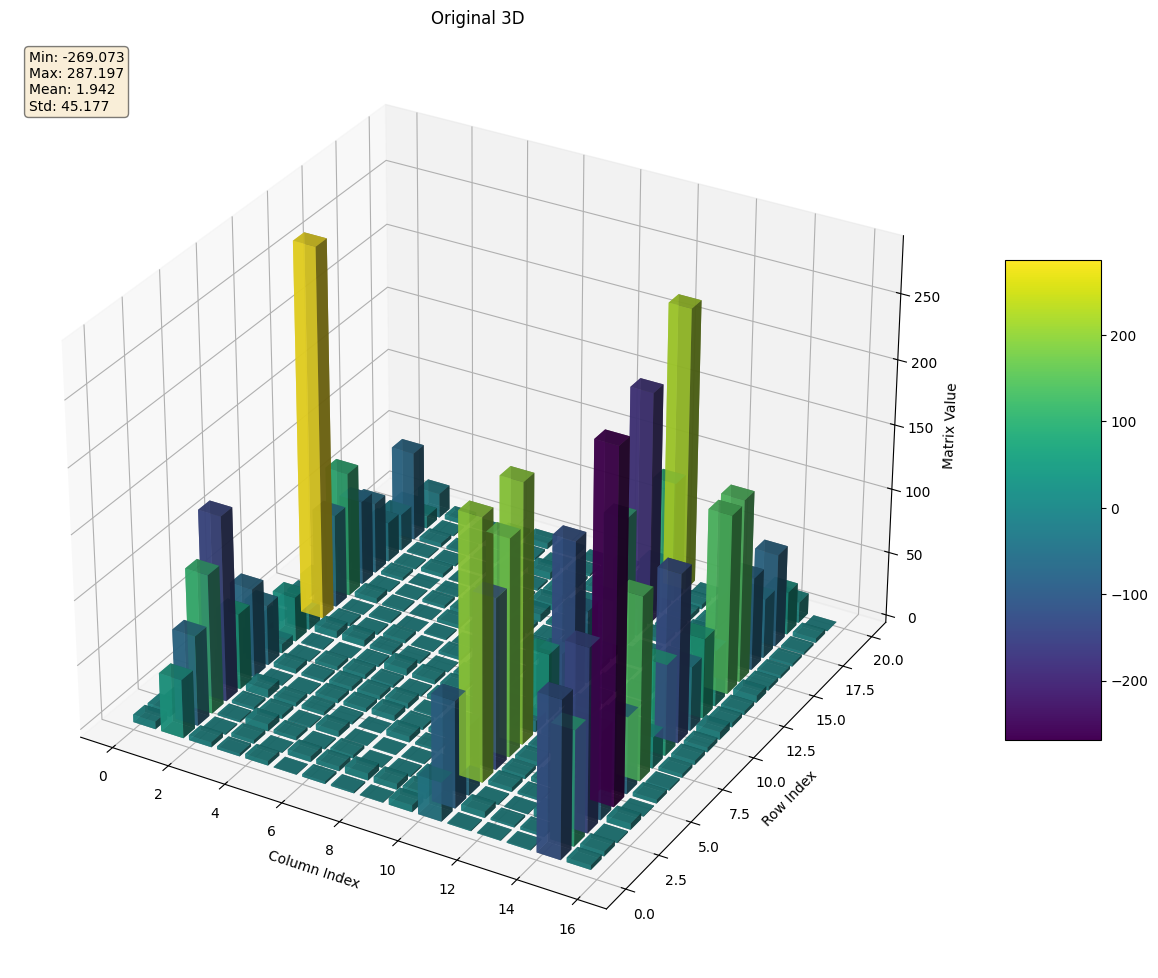

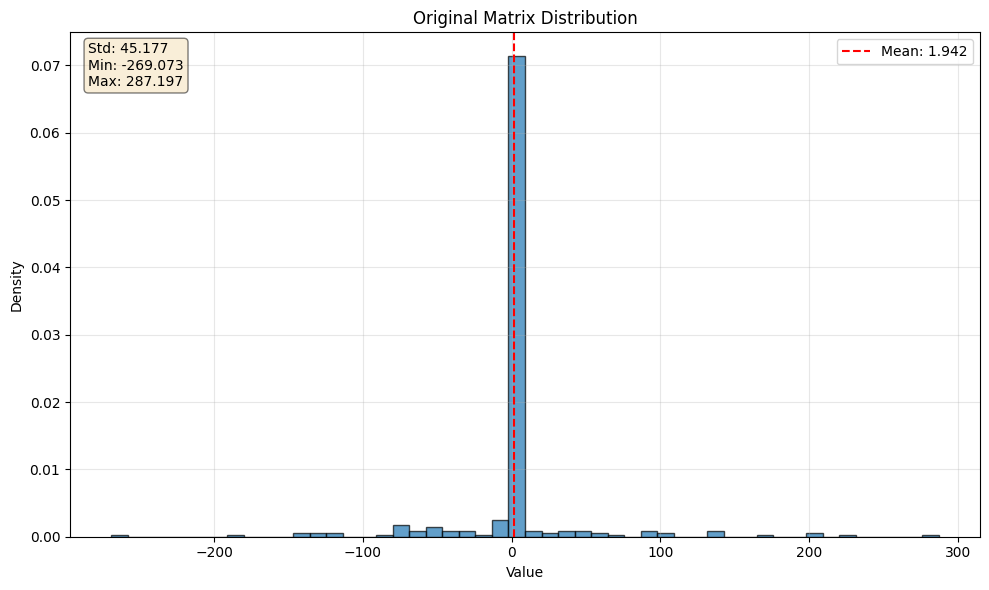

Hadamard matrix shape: torch.Size([16, 16])


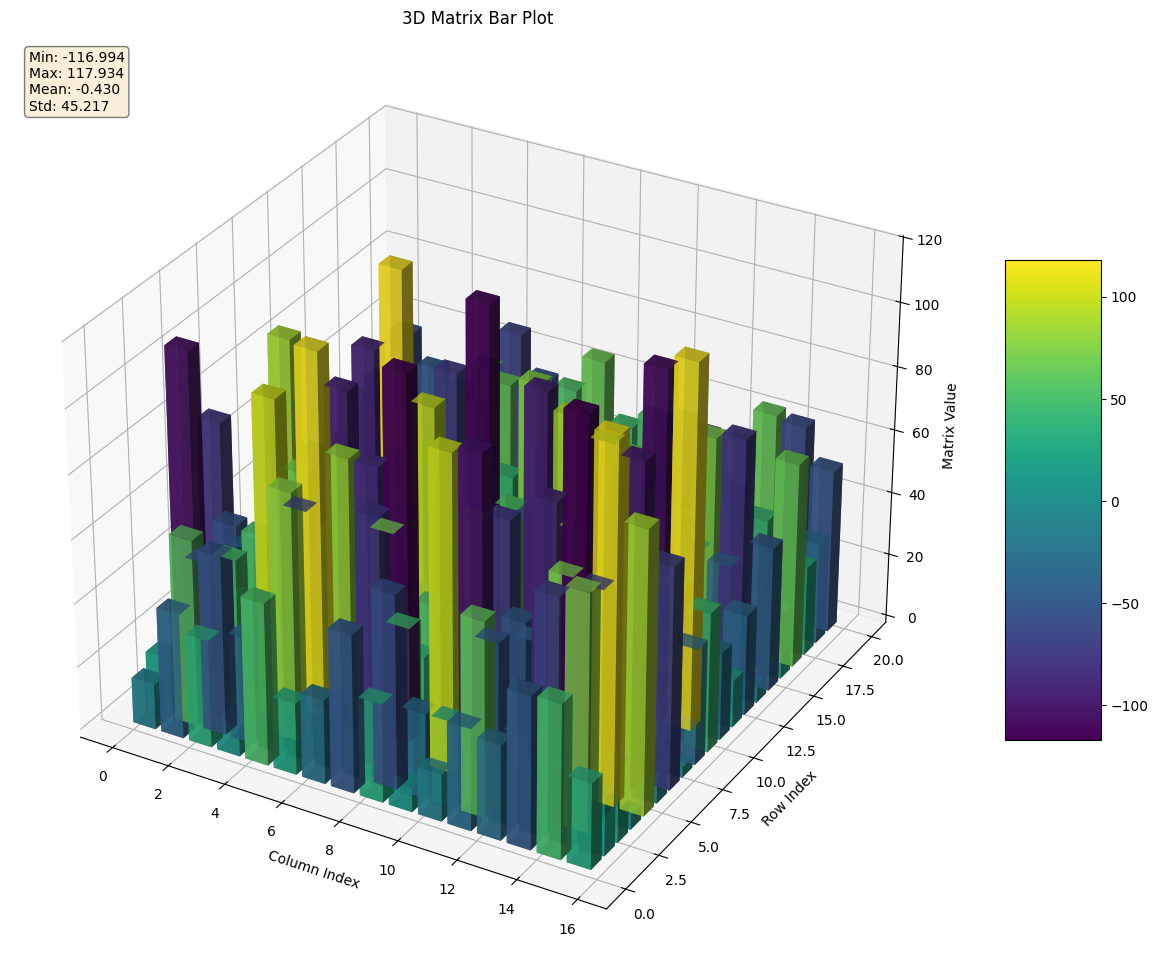

/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_355313/3436955976.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_355313/3436955976.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


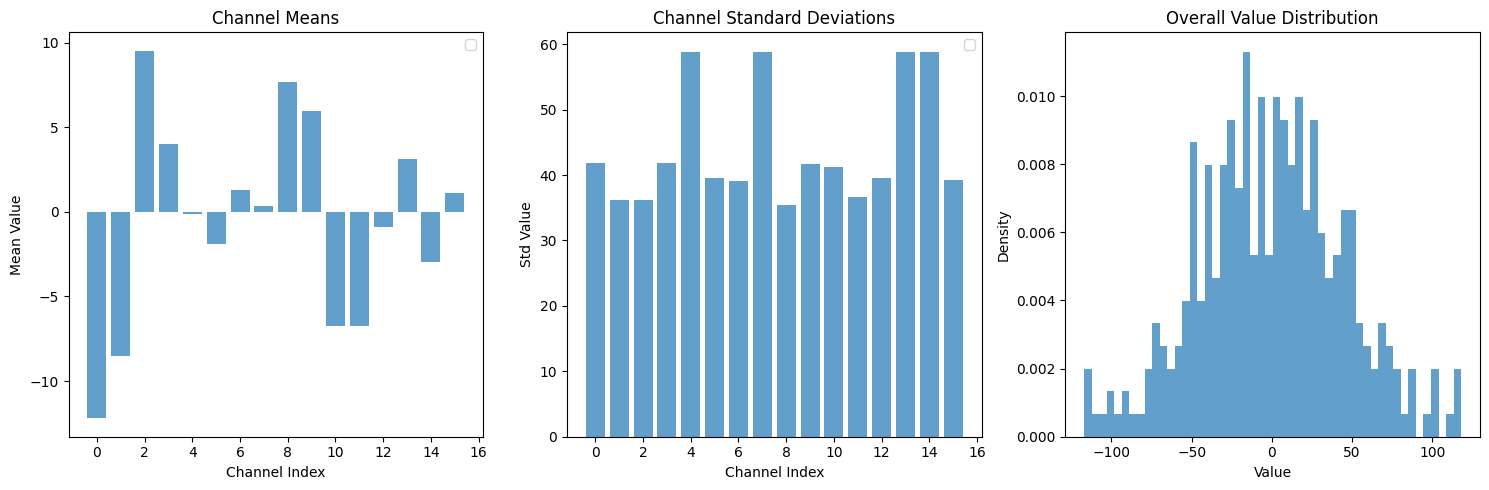

After 1 rotation(s) - Mean: -0.429809, Std: 45.287327
Min: -116.994382, Max: 117.933876
--------------------------------------------------


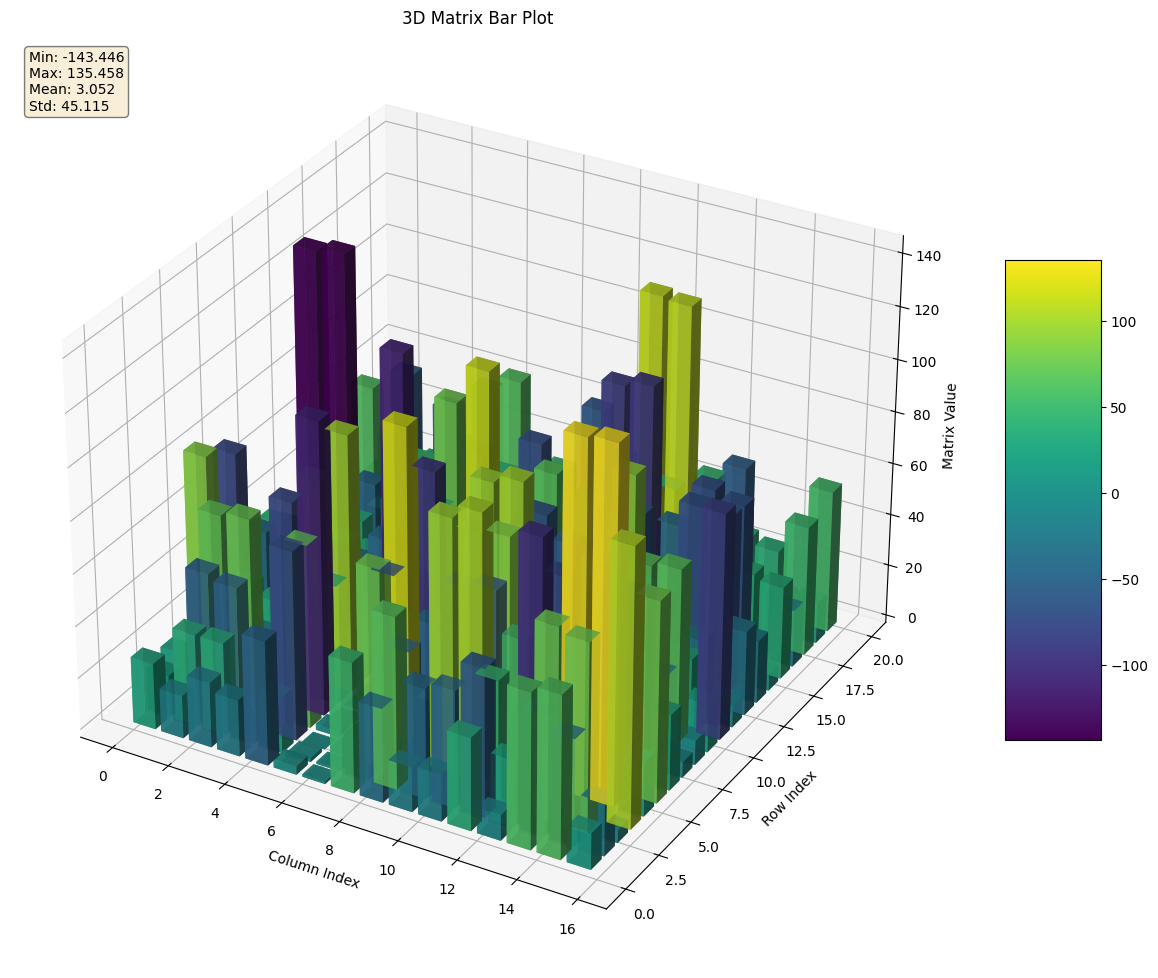

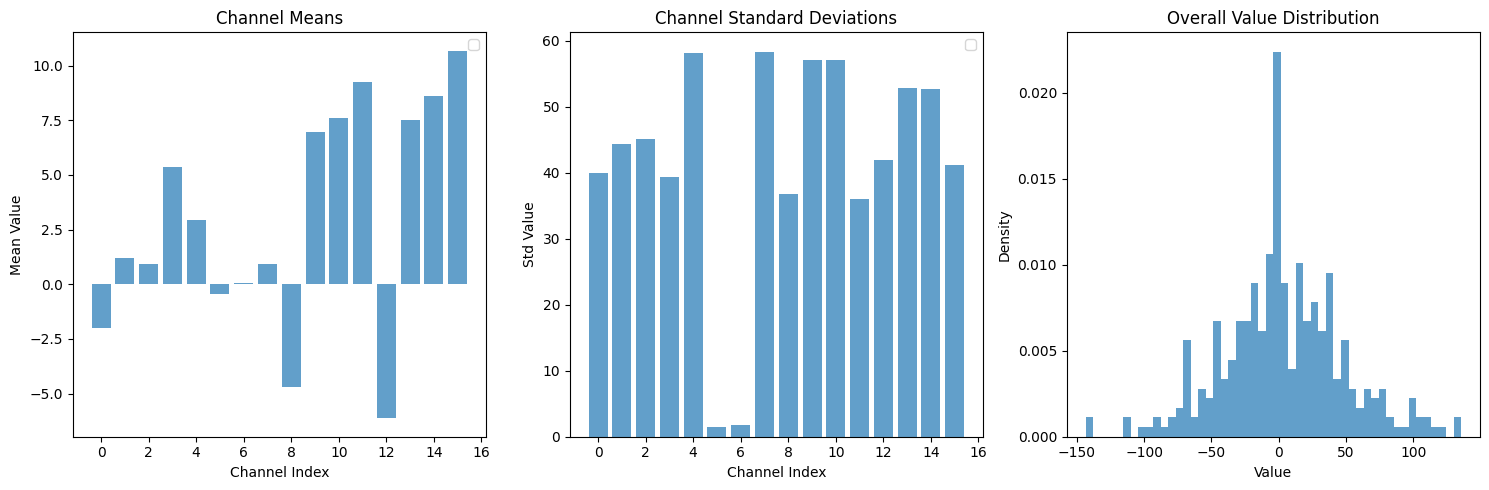

After 2 rotation(s) - Mean: 3.052083, Std: 45.186092
Min: -143.446425, Max: 135.457879
--------------------------------------------------


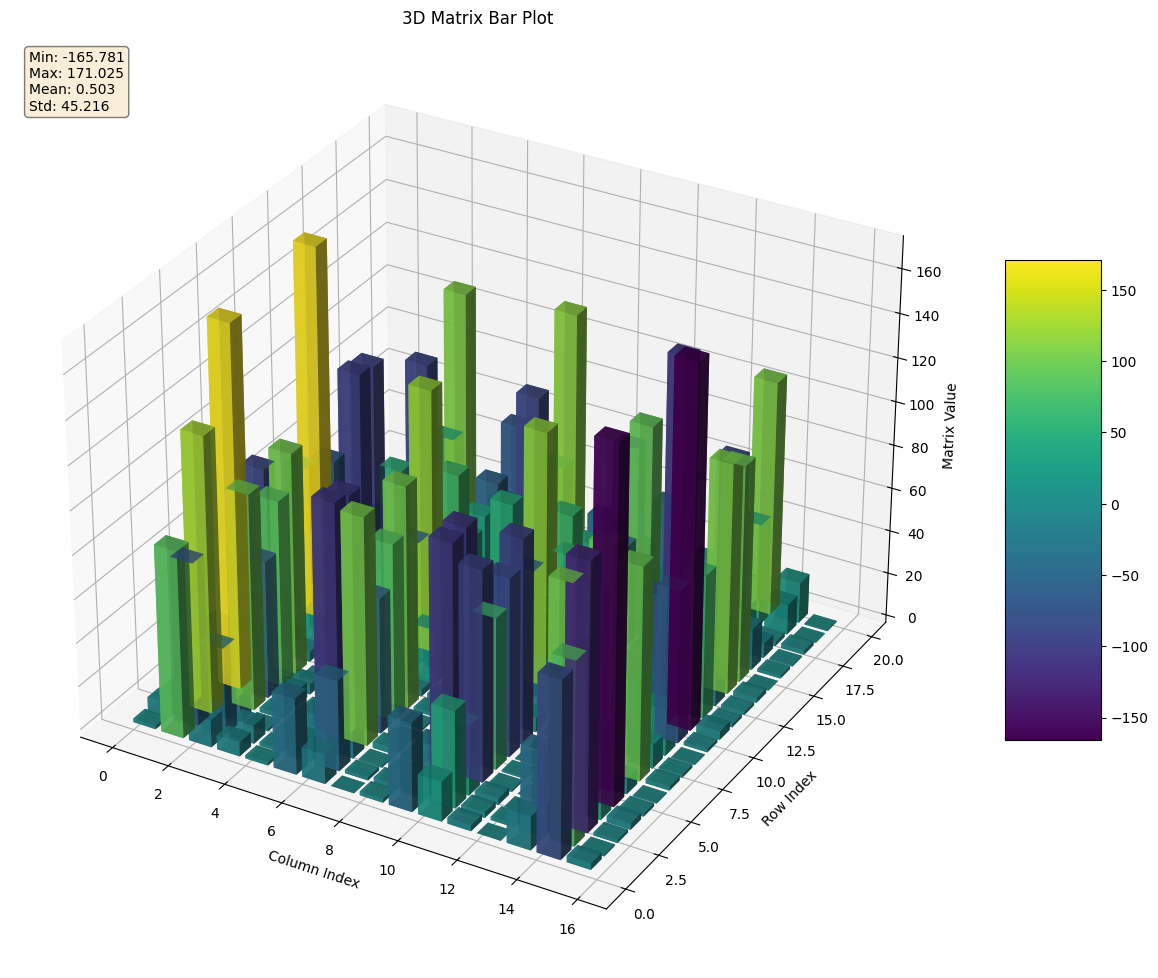

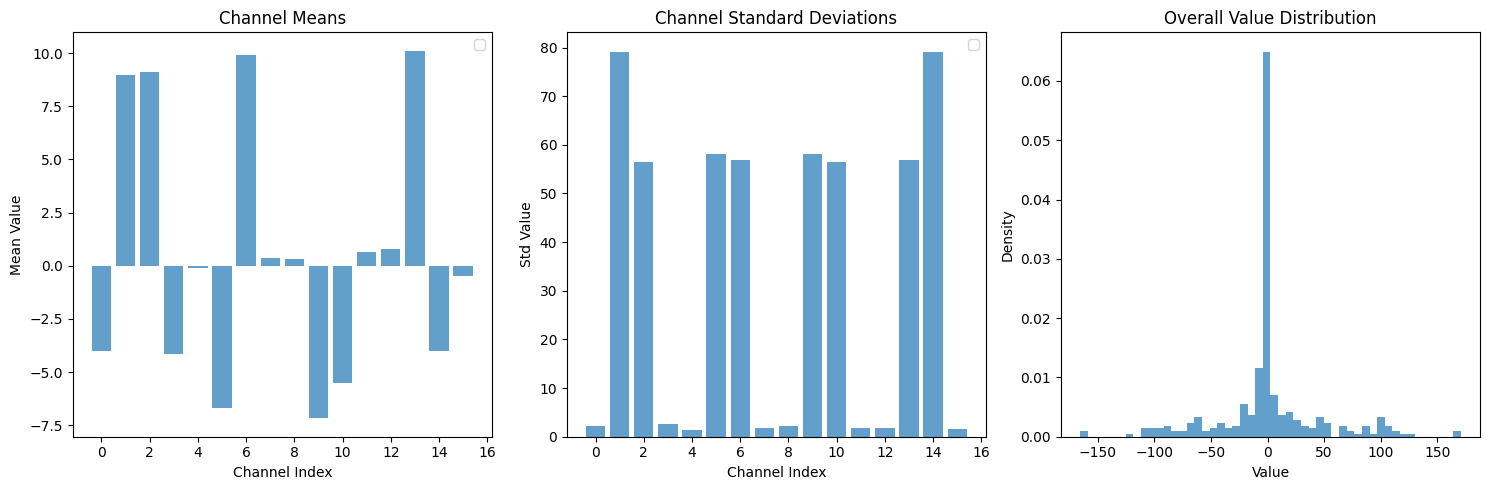

After 3 rotation(s) - Mean: 0.503358, Std: 45.286567
Min: -165.780772, Max: 171.024881
--------------------------------------------------


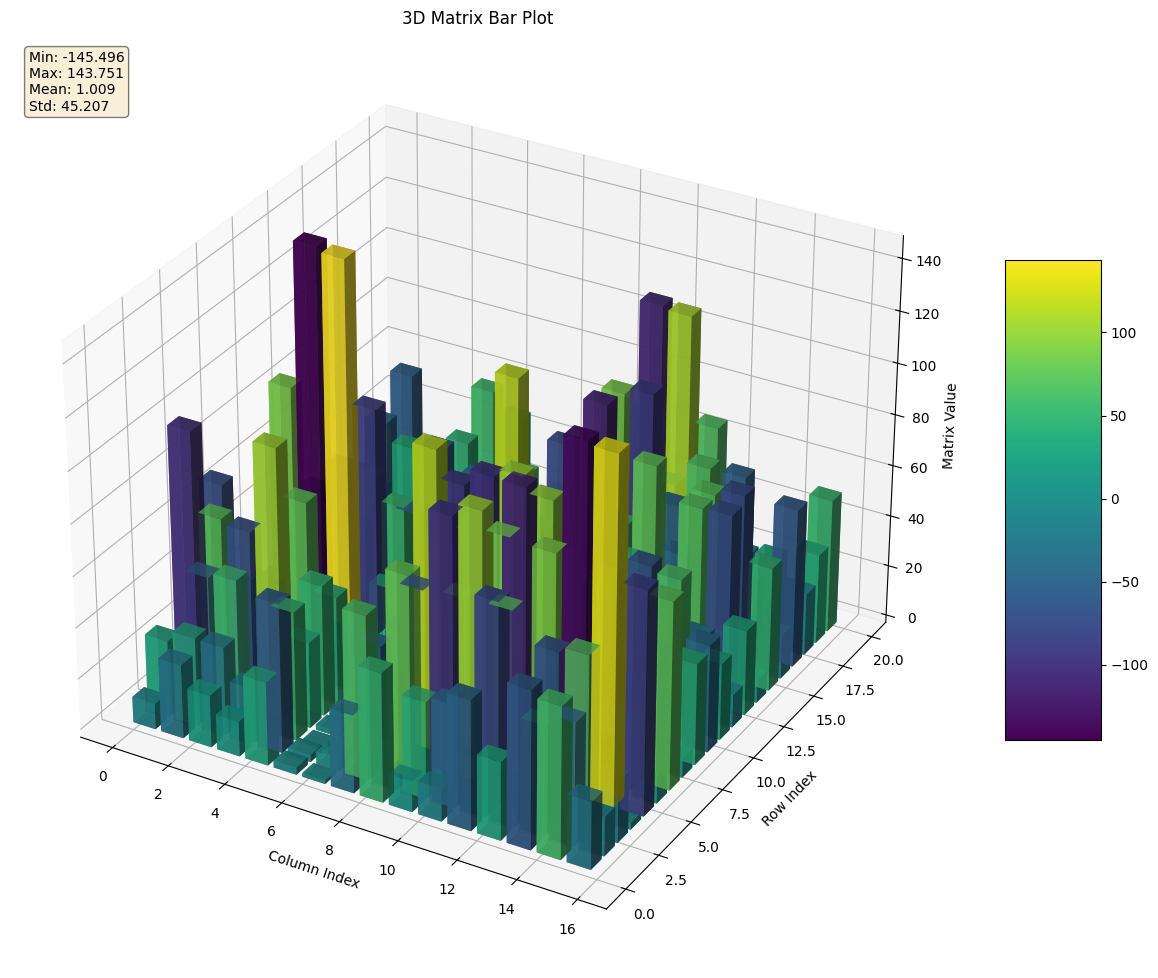

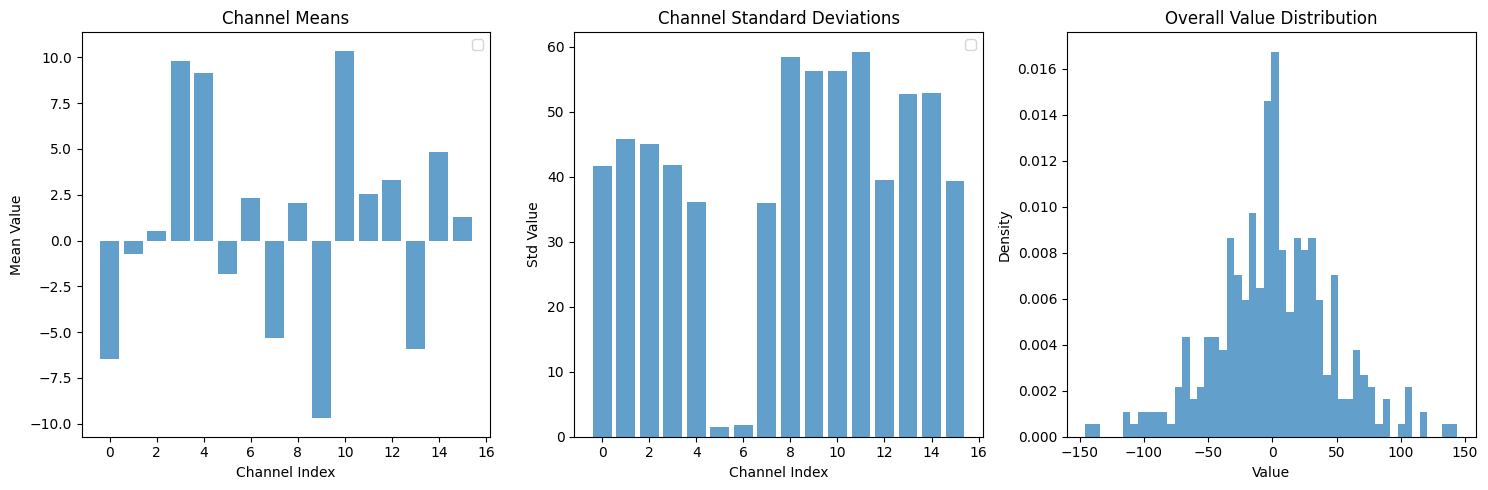

After 4 rotation(s) - Mean: 1.008752, Std: 45.278102
Min: -145.496144, Max: 143.751054
--------------------------------------------------


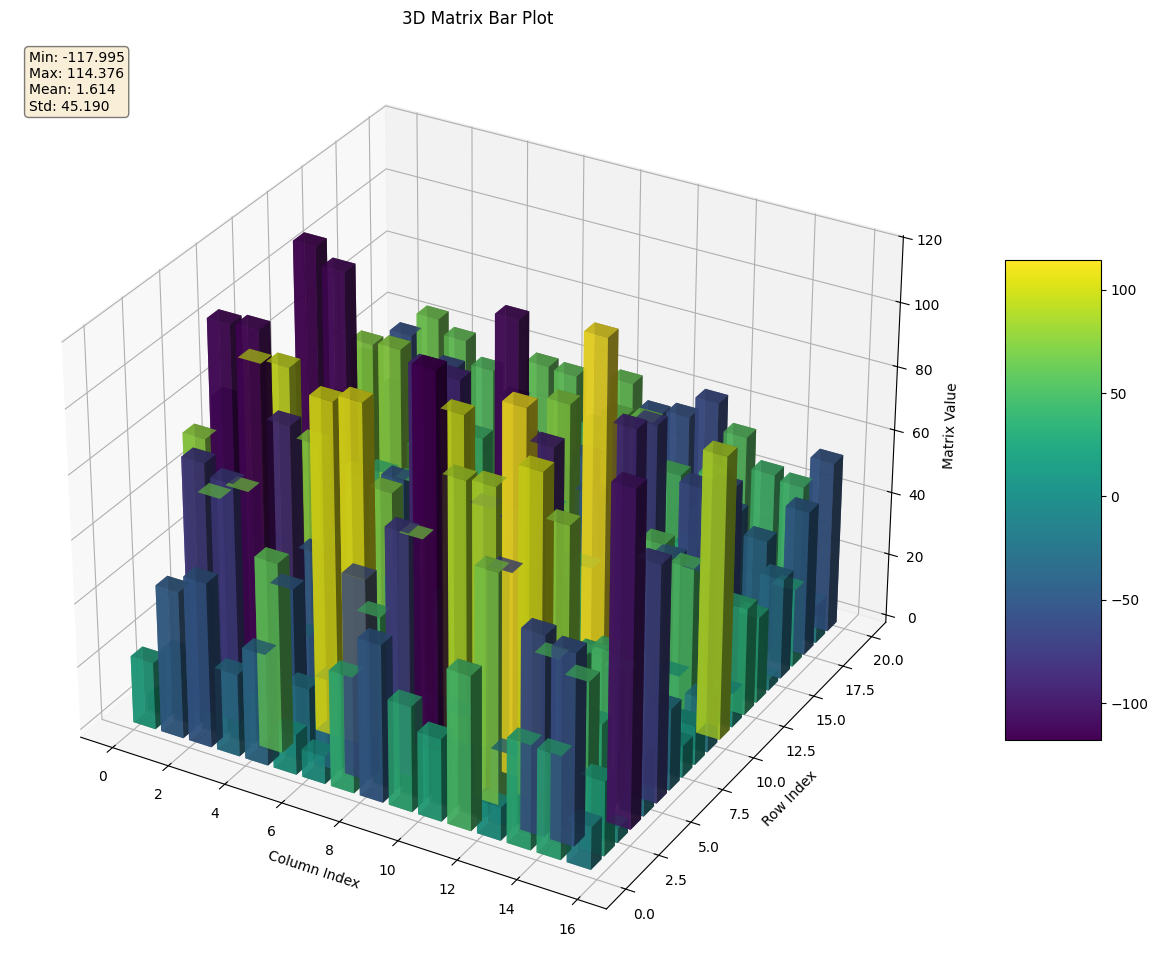

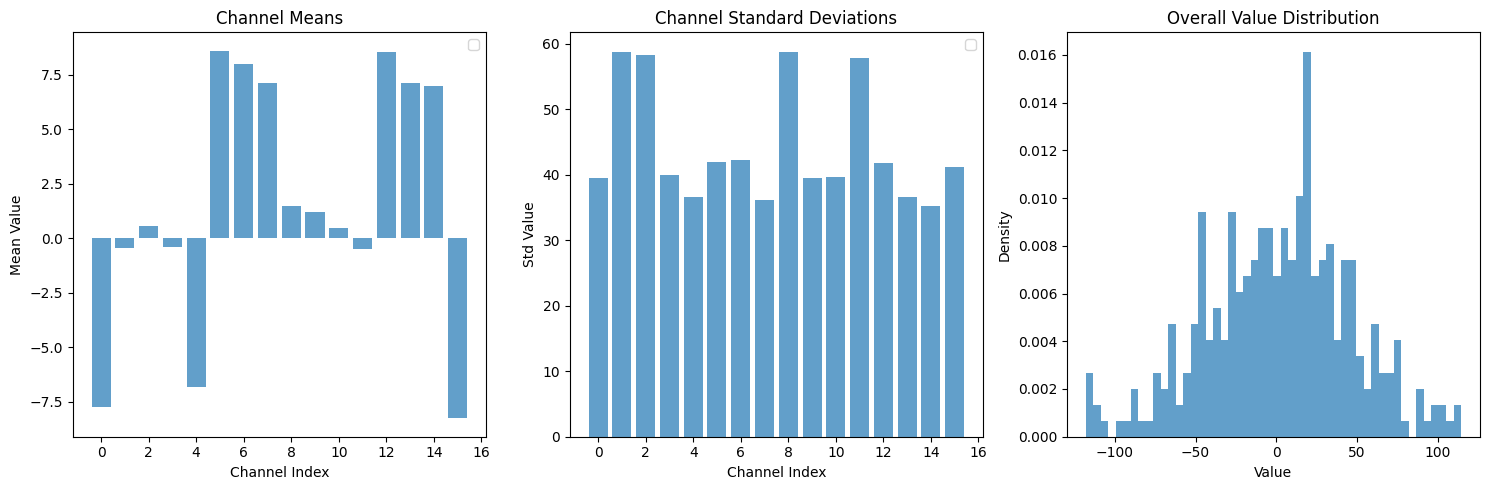

After 5 rotation(s) - Mean: 1.613522, Std: 45.260531
Min: -117.994576, Max: 114.375521
--------------------------------------------------


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
channels = 16
row_channels = 20
# Define which channels should be outliers
outlier_channels = [1,10,14] 

# Generate matrix with channel-specific outliers
test_matrix = generate_matrix_with_channel_outliers(
    rows=row_channels, 
    cols=channels, 
    outlier_channels=outlier_channels,
    normal_mean=2.0,
    normal_std=2.0,
    outlier_mean=100,
    outlier_std=10,
    seed=seed
).to(device).double()
print(f"Original matrix shape: {test_matrix.shape}")
plot_matrix_3d_bars(test_matrix,"Original 3D")
distribution_plot(test_matrix, "Original Matrix Distribution")

# Generate Hadamard matrix
hadamard_matrix = rotation_utils.get_orthogonal_matrix(
    size=channels, 
    mode='hadamard', 
    device=device, 
    seed=seed
)

print(f"Hadamard matrix shape: {hadamard_matrix.shape}")

# Apply multiple Hadamard rotations and plot distributions
current_matrix = test_matrix.clone()
num_rotations = 5

for i in range(1, num_rotations + 1):
    # Apply Hadamard rotation
    current_matrix = torch.matmul(current_matrix, hadamard_matrix)
    plot_matrix_3d_bars(current_matrix)
    plot_channel_statistics(current_matrix, num_channels_to_show=channels)
    # distribution_plot(
    #     current_matrix, 
    #     f"Distribution after {i} Hadamard rotation{'s' if i > 1 else ''}"
    # )
    
    print(f"After {i} rotation(s) - Mean: {current_matrix.mean():.6f}, Std: {current_matrix.std():.6f}")
    print(f"Min: {current_matrix.min():.6f}, Max: {current_matrix.max():.6f}")
    print("-" * 50)


Original matrix shape: torch.Size([100, 64])


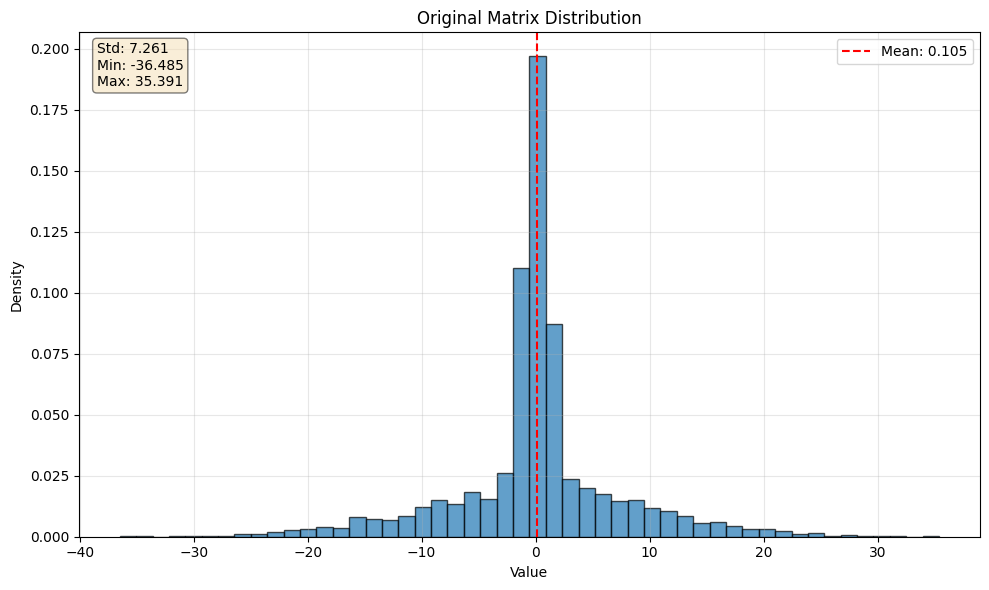

Hadamard matrix shape: torch.Size([64, 64])


/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_355313/3436955976.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/ubuntu/21chi.nh/Drone/TestTrainEvcap/tmp/ipykernel_355313/3436955976.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


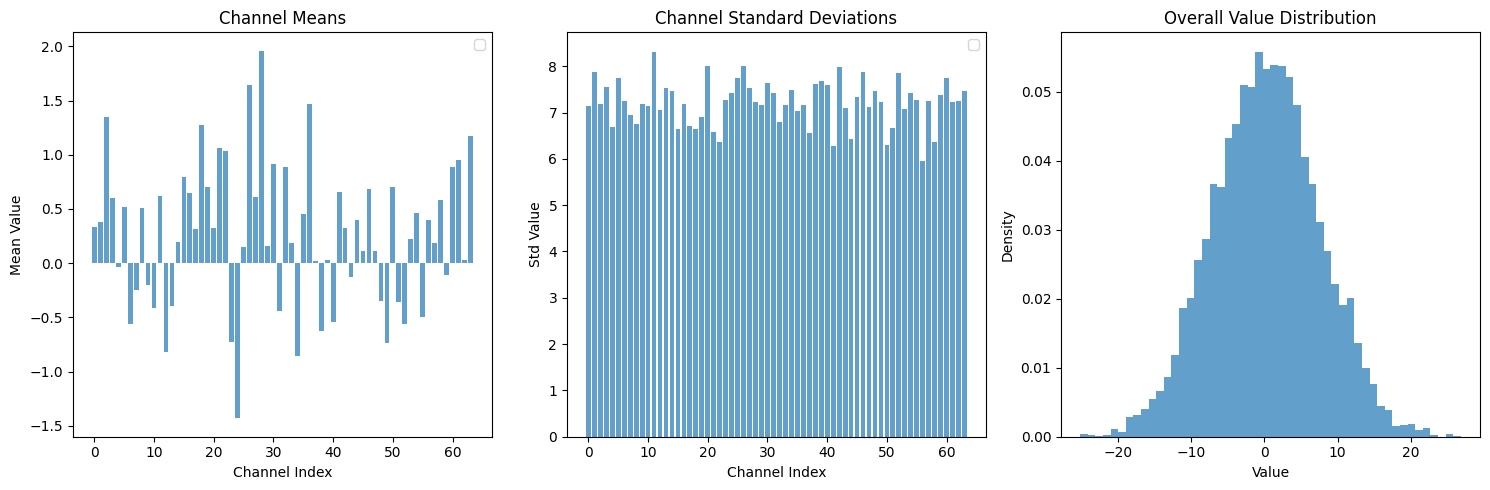

After 1 rotation(s) - Mean: 0.265430, Std: 7.257020
Min: -25.141187, Max: 26.813130
--------------------------------------------------


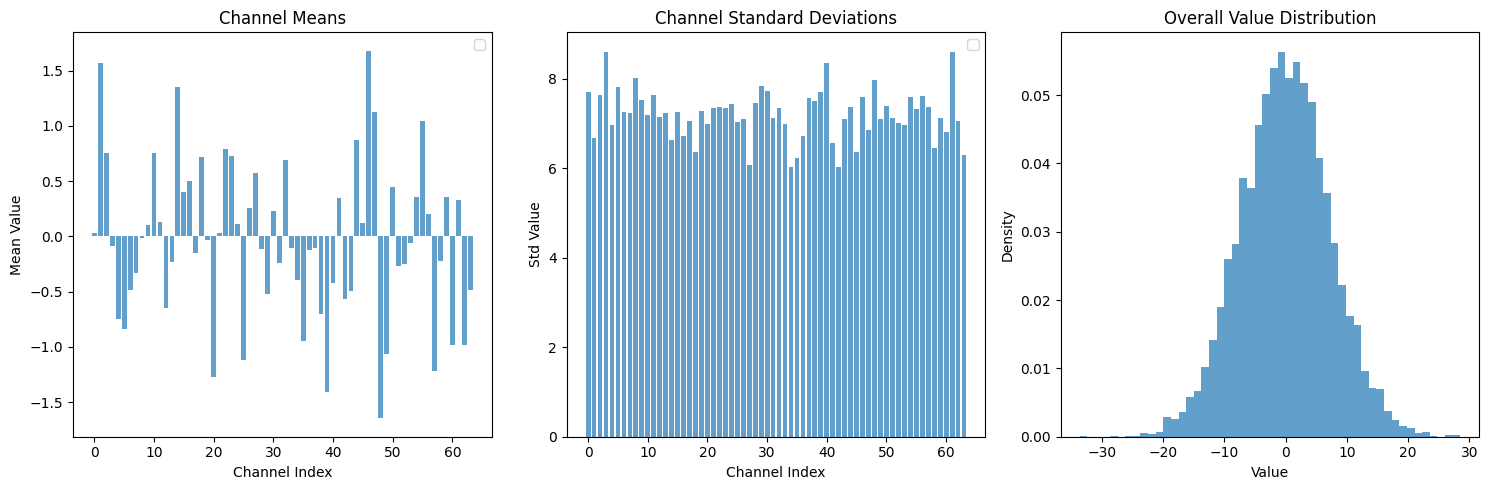

After 2 rotation(s) - Mean: -0.041454, Std: 7.261755
Min: -33.606796, Max: 28.499971
--------------------------------------------------


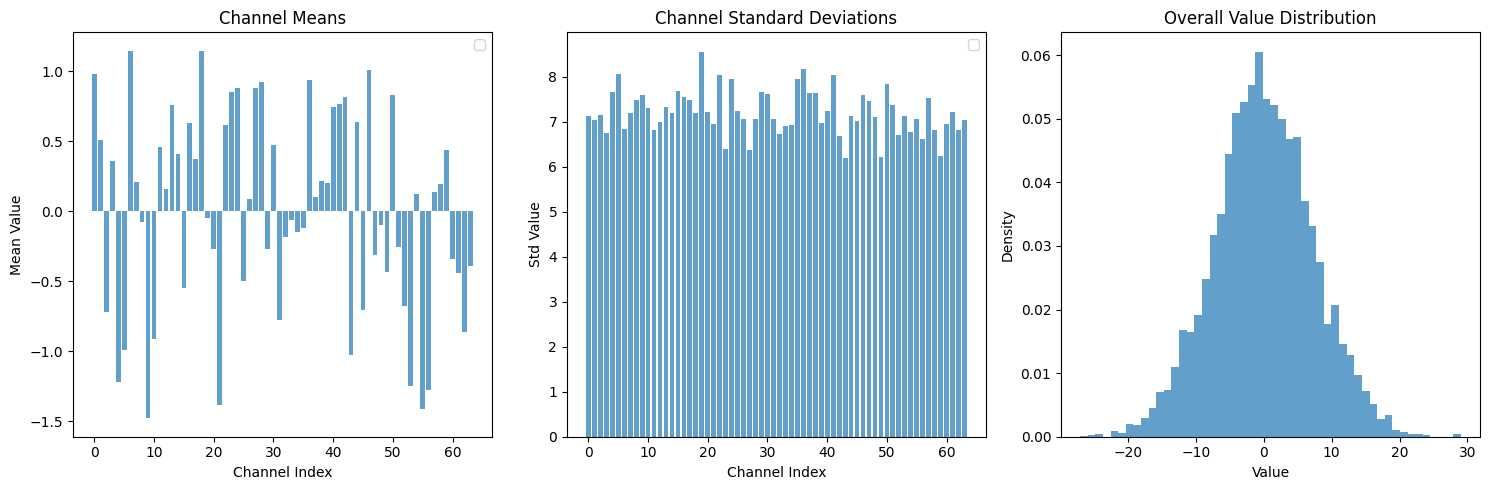

After 3 rotation(s) - Mean: -0.003636, Std: 7.261872
Min: -27.063093, Max: 29.043470
--------------------------------------------------


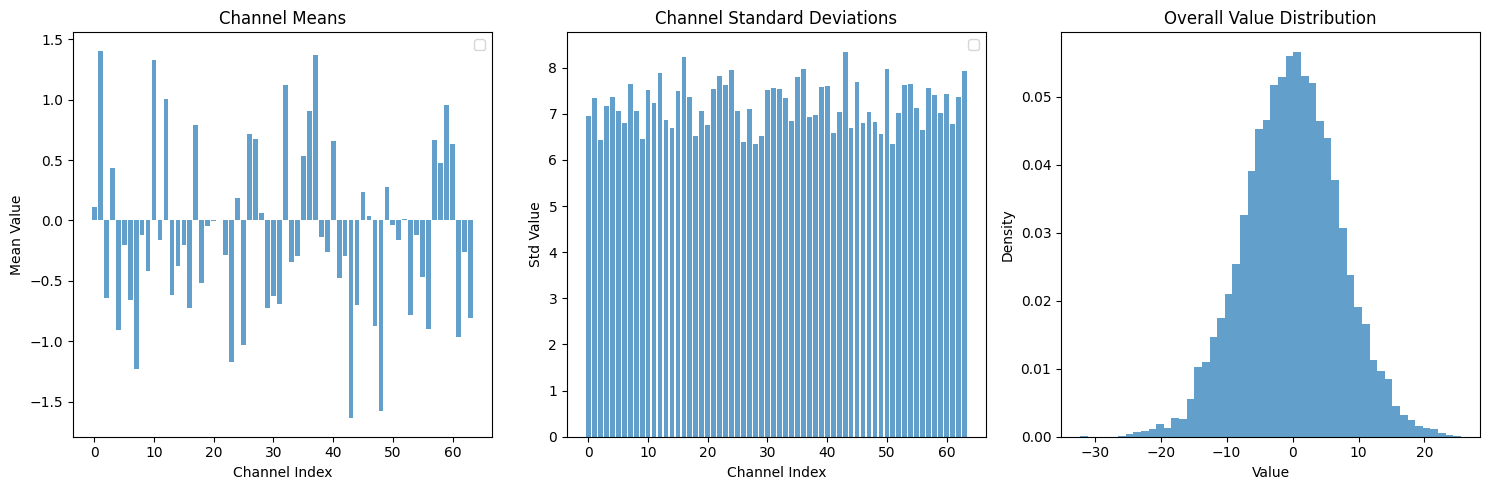

After 4 rotation(s) - Mean: -0.122503, Std: 7.260840
Min: -32.235612, Max: 25.537482
--------------------------------------------------


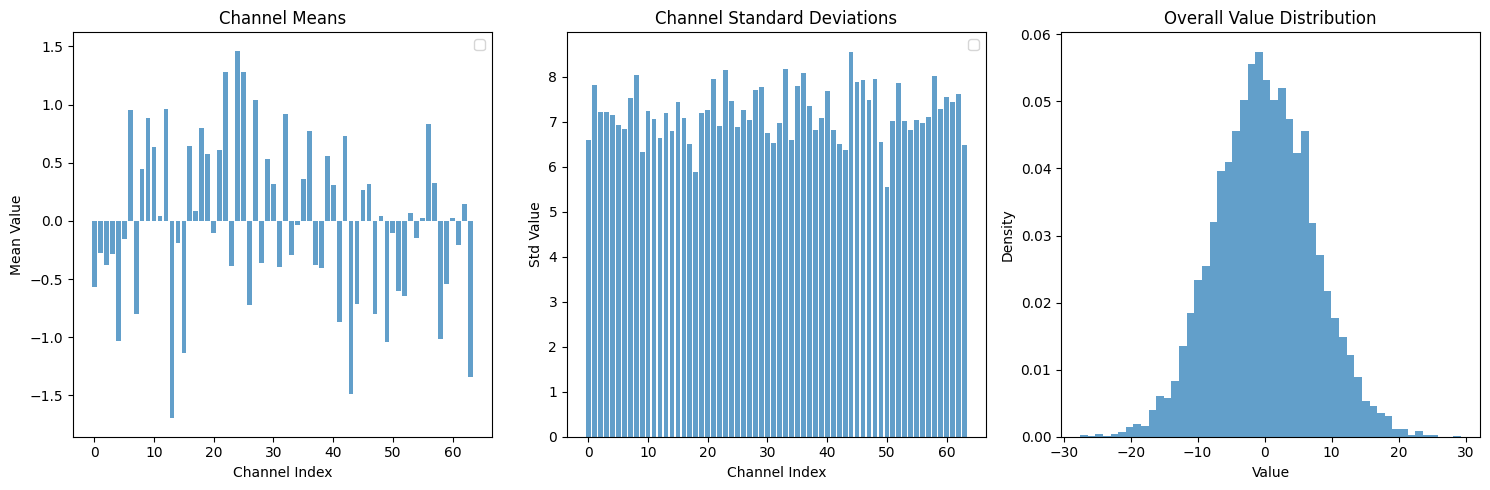

After 5 rotation(s) - Mean: -0.013640, Std: 7.261860
Min: -27.548042, Max: 29.315320
--------------------------------------------------


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
channels =64
row_channels = 100
# Generate test matrix with outliers
test_matrix = generate_matrix_with_outliers(
    rows=row_channels, 
    cols=channels, 
    outlier_ratio=0.5, 
    normal_std=1.0, 
    outlier_std=10.0, 
    seed=seed
).to(device).double()

print(f"Original matrix shape: {test_matrix.shape}")
distribution_plot(test_matrix, "Original Matrix Distribution")

# Generate Hadamard matrix
hadamard_matrix = rotation_utils.get_orthogonal_matrix(
    size=channels, 
    mode='hadamard', 
    device=device, 
    seed=seed
)

print(f"Hadamard matrix shape: {hadamard_matrix.shape}")

# Apply multiple Hadamard rotations and plot distributions
current_matrix = test_matrix.clone()
num_rotations = 5

for i in range(1, num_rotations + 1):
    # Apply Hadamard rotation
    current_matrix = torch.matmul(current_matrix, hadamard_matrix)
    
    plot_channel_statistics(current_matrix, num_channels_to_show=channels)
    # distribution_plot(
    #     current_matrix, 
    #     f"Distribution after {i} Hadamard rotation{'s' if i > 1 else ''}"
    # )
    
    print(f"After {i} rotation(s) - Mean: {current_matrix.mean():.6f}, Std: {current_matrix.std():.6f}")
    print(f"Min: {current_matrix.min():.6f}, Max: {current_matrix.max():.6f}")
    print("-" * 50)